# Kiva Microfinance — Data Exploration & Applied Machine Learning

An end-to-end analysis of the Kiva crowdfunding dataset: from data cleaning and exploratory analysis, through unsupervised clustering and a recommendation prototype, to supervised regression models (Linear Regression, Random Forest, XGBoost) with SHAP-based explainability.

## What is Kiva?

Kiva is a nonprofit organisation that lets individuals lend small amounts of money to low-income entrepreneurs and students across 77 countries. This dataset documents those loan activities and offers a window into topics such as global development, social impact, and microfinance.

## Problem statement

This project investigates how borrower and loan characteristics — geographic location, sector, currency, number of lenders, loan term, and repayment interval — relate to the **loan amount** disbursed through Kiva.

The goal is to quantify these relationships, surface systemic patterns in how loans are allocated, and assess how well the loan amount can be predicted from these features.

## Methodological approach

1. Loading, isolating, and cleaning the data
2. Exploratory data analysis (descriptive statistics & correlation)
3. Unsupervised learning (clustering & a recommendation prototype)
4. Supervised learning (regression) with model explainability

## The columns used in this analysis

To follow the code and interpret its output, it helps to know what the selected columns represent:

- **`loan_amount`** — the amount (USD) disbursed to the borrower; the target variable in the modelling sections.
- **`sector`** — the high-level category of the funded activity (e.g. Agriculture, Food, Retail).
- **`country`** — the borrower's country.
- **`currency`** — the currency in which the loan was disbursed.
- **`lender_count`** — the number of lenders who contributed to the loan.
- **`term_in_months`** — the repayment term of the loan, in months.
- **`repayment_interval`** — how repayments are scheduled (e.g. monthly, irregular, bullet).

#1. Loading, isolating and cleaning data

In [ ]:
# Package installs (uncomment if running in a fresh environment such as Google Colab)
!pip install kmodes -q
!pip install xgboost -q
!pip install shap -q
!pip install imbalanced-learn -q

In [ ]:
import pandas as pd  # Data exploration, cleaning, manipulation, and analysis
import numpy as np  # Optimized mathematical computations
import matplotlib.pyplot as plt  # Visualization library
import seaborn as sns  # Statistical graphics in Python
import scipy.sparse as ss

from scipy.cluster.hierarchy import linkage, dendrogram  # Hierarchical clustering / dendrograms
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder  # Preprocessing tools
from sklearn.cluster import KMeans, AgglomerativeClustering  # Clustering algorithms
from kmodes.kmodes import KModes  # Categorical clustering
from sklearn.decomposition import TruncatedSVD  # Dimensionality reduction
from sklearn.metrics.pairwise import cosine_distances  # Distance metrics
from sklearn.model_selection import train_test_split  # Train-test split
from sklearn.linear_model import LinearRegression  # Linear model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Model evaluation metrics
from sklearn.compose import ColumnTransformer  # Column transformation
from sklearn.ensemble import RandomForestRegressor  # Random Forest algorithm
from sklearn.impute import KNNImputer  # Missing data imputation
from imblearn.under_sampling import RandomUnderSampler  # Imbalance handling
from xgboost import XGBRegressor  # Gradient boosting model
import shap  # SHAP for explainability
import joblib  # Model saving and loading

%matplotlib inline

In [ ]:
# Load the dataset. Place the CSV files from the Kaggle "Data Science for Good:
# Kiva Crowdfunding" dataset in a local ./data folder (see README for details).
DATA_DIR = "data"

df_1 = pd.read_csv(f"{DATA_DIR}/kiva_loans_part_0.csv")
df_2 = pd.read_csv(f"{DATA_DIR}/kiva_loans_part_1.csv")
df_3 = pd.read_csv(f"{DATA_DIR}/kiva_loans_part_2.csv")
df_4 = pd.read_csv(f"{DATA_DIR}/kiva_mpi_region_locations.csv")
df_5 = pd.read_csv(f"{DATA_DIR}/loan_theme_ids.csv")
df_6 = pd.read_csv(f"{DATA_DIR}/loan_themes_by_region.csv")

# Combine the source files. The columns used downstream come from the loan files;
# rows lacking those columns are removed during the cleaning step below.
data = pd.concat([df_1, df_2, df_3, df_4, df_5, df_6])

In [ ]:
# Displaying the first five rows of our dataset
data.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,Field Partner Name,forkiva,geocode_old,number,amount,geocode,names,mpi_region,mpi_geo,rural_pct
0,653051.0,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,653053.0,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,653068.0,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,653063.0,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,653084.0,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Gaining further insight into the available data: data types, number of entries, etc.
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1468805 entries, 0 to 15735
Data columns (total 40 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1450297 non-null  float64
 1   funded_amount       671205 non-null   float64
 2   loan_amount         671205 non-null   float64
 3   activity            671205 non-null   object 
 4   sector              686941 non-null   object 
 5   use                 666973 non-null   object 
 6   country_code        671197 non-null   object 
 7   country             687949 non-null   object 
 8   region              631125 non-null   object 
 9   currency            671205 non-null   object 
 10  partner_id          657698 non-null   float64
 11  posted_time         671205 non-null   object 
 12  disbursed_time      668809 non-null   object 
 13  funded_time         622874 non-null   object 
 14  term_in_months      671205 non-null   float64
 15  lender_count        67

In [ ]:
#Isolating a part of the data set
df = data[['loan_amount', 'sector', 'country', 'currency', 'lender_count', 'term_in_months', 'repayment_interval']]
df.head()

,loan_amount,sector,country,currency,lender_count,term_in_months,repayment_interval
0,300.0,Food,Pakistan,PKR,12.0,12.0,irregular
1,575.0,Transportation,Pakistan,PKR,14.0,11.0,irregular
2,150.0,Transportation,India,INR,6.0,43.0,bullet
3,200.0,Arts,Pakistan,PKR,8.0,11.0,irregular
4,400.0,Food,Pakistan,PKR,16.0,14.0,monthly


In [ ]:
# Useing .dropna(inplace=True) we remove rows with missing values in the original dataset (df)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 671205 entries, 0 to 221204
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   loan_amount         671205 non-null  float64
 1   sector              671205 non-null  object 
 2   country             671205 non-null  object 
 3   currency            671205 non-null  object 
 4   lender_count        671205 non-null  float64
 5   term_in_months      671205 non-null  float64
 6   repayment_interval  671205 non-null  object 
dtypes: float64(3), object(4)
memory usage: 41.0+ MB


<ipython-input-8-9174d45f281f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


#2. EDA

In [ ]:
# Using .describe() to gain insight into key statistical metrics of our selected dataset
df.describe()

,loan_amount,lender_count,term_in_months
count,671205.000000,671205.000000,671205.000000
mean,842.397107,20.590922,13.739022
std,1198.660073,28.459551,8.598919
min,25.000000,0.000000,1.000000
25%,275.000000,7.000000,8.000000
50%,500.000000,13.000000,13.000000
75%,1000.000000,24.000000,14.000000
max,100000.000000,2986.000000,158.000000


In [ ]:
# The isolated dataframe is skewed by outliers, which we address using the interquartile range (IQR).
# Calculate the quartiles of the target variable
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1

# Filter data within the IQR bounds
df_core = df[(df['loan_amount'] >= Q1 - 1.5 * IQR) & (df['loan_amount'] <= Q3 + 1.5 * IQR)]
df_core.info()

<class 'pandas.core.frame.DataFrame'>
Index: 620212 entries, 0 to 221204
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   loan_amount         620212 non-null  float64
 1   sector              620212 non-null  object 
 2   country             620212 non-null  object 
 3   currency            620212 non-null  object 
 4   lender_count        620212 non-null  float64
 5   term_in_months      620212 non-null  float64
 6   repayment_interval  620212 non-null  object 
dtypes: float64(3), object(4)
memory usage: 37.9+ MB


In [ ]:
# Our new key statistical metrics
df_core.describe()

,loan_amount,lender_count,term_in_months
count,620212.000000,620212.000000,620212.000000
mean,585.123595,16.000277,13.502843
std,437.383488,13.371089,7.835742
min,25.000000,0.000000,1.000000
25%,250.000000,7.000000,8.000000
50%,450.000000,12.000000,13.000000
75%,800.000000,21.000000,14.000000
max,2075.000000,137.000000,141.000000


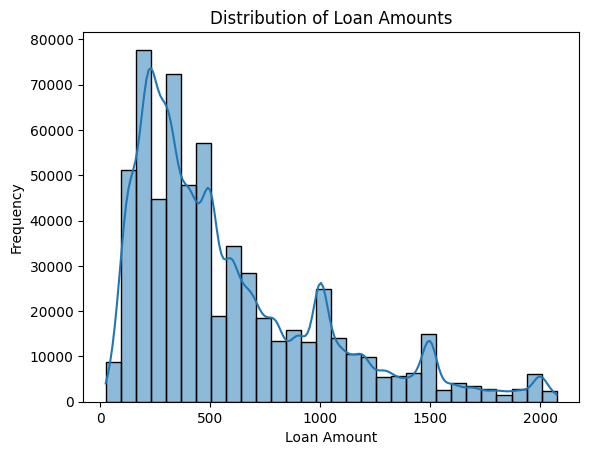

In [ ]:
# using seaborn to plot loan amount based of frequency
sns.histplot(df_core['loan_amount'], bins=30, kde=True)
plt.title('Distribution of Loan Amounts')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()

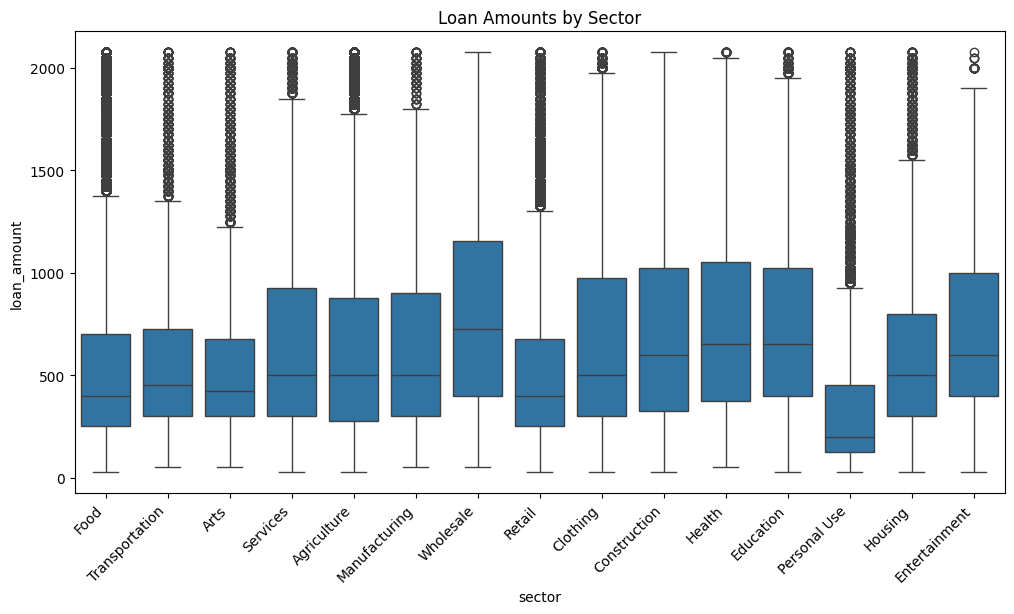

In [ ]:
# Creating multiple boxplots on loan amount spread out on sectors
plt.figure(figsize=(12, 6))
sns.boxplot(x='sector', y='loan_amount', data=df_core)
plt.title('Loan Amounts by Sector')
plt.xticks(rotation=45, ha='right')
plt.show()

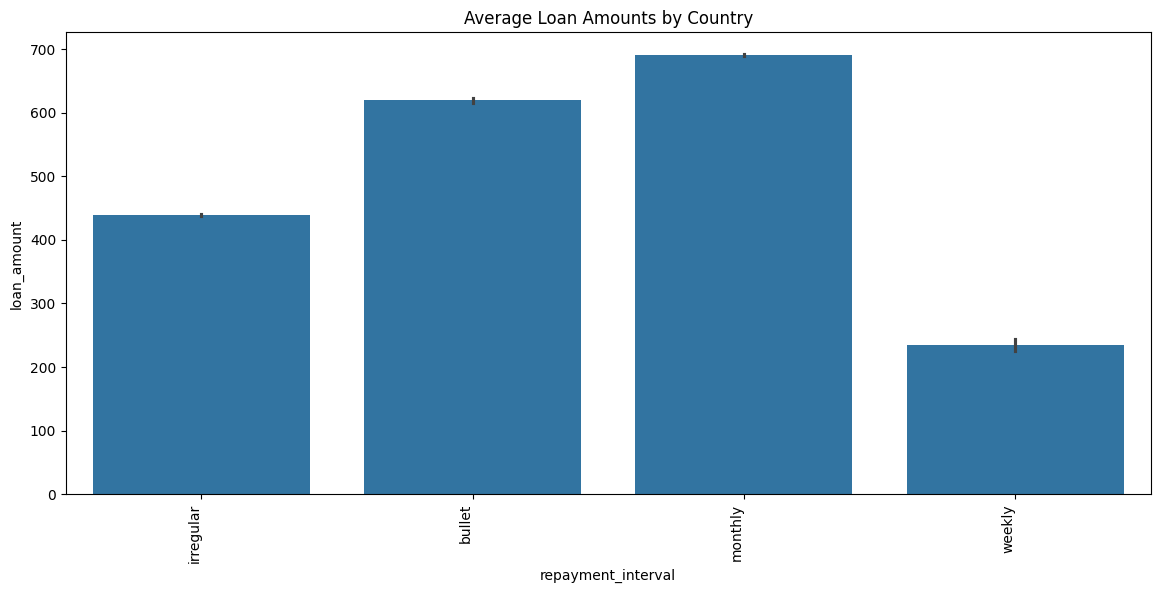

In [ ]:
# Using seaborn to plot the average loan amount based of repayment interval
plt.figure(figsize=(14, 6))
sns.barplot(x='repayment_interval', y='loan_amount', data=df_core, estimator=np.mean)
plt.title('Average Loan Amounts by Repayment Interval')
plt.xticks(rotation=90, ha='right')
plt.show()

In [ ]:
# Use groupby to look at the average loan amount for every sector across each repayment interval
df_core.groupby(['sector', 'repayment_interval'])['loan_amount'].mean()

sector          repayment_interval
Agriculture     bullet                655.898141
                irregular             435.389347
                monthly               699.461666
                weekly                201.923077
Arts            bullet                613.775065
                irregular             451.509171
                monthly               640.991168
                weekly                240.000000
Clothing        bullet                588.600892
                irregular             523.471909
                monthly               776.336568
                weekly                256.521739
Construction    bullet                559.622642
                irregular             529.683048
                monthly               820.536829
                weekly                225.000000
Education       bullet                372.645994
                irregular             790.273376
                monthly               795.521871
Entertainment   bullet                809.705882
                irregular             523.529412
                monthly               889.209726
Food            bullet                597.295285
                irregular             431.799620
                monthly               711.735294
                weekly                229.896907
Health          bullet                711.864407
                irregular             742.143906
                monthly               776.920834
                weekly                332.692308
Housing         bullet                602.523202
                irregular             320.962505
                monthly               721.602024
Manufacturing   bullet                578.192771
                irregular             480.690099
                monthly               789.545455
Personal Use    bullet                335.699873
                irregular             359.052369
                monthly               362.404291
Retail          bullet                643.909900
                irregular             416.516652
                monthly               711.535771
                weekly                231.854839
Services        bullet                717.690460
                irregular             486.934505
                monthly               711.244951
                weekly                221.078431
Transportation  bullet                542.724868
                irregular             435.919815
                monthly               672.323608
                weekly                227.083333
Wholesale       bullet                720.312500
                irregular             632.615894
                monthly               937.463768
Name: loan_amount, dtype: float64

In [ ]:
# Create a copy of the dataframe to avoid modifying the original
df_encoded = df_core.copy()

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical features
for col in ['sector', 'country', 'currency', 'repayment_interval']:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

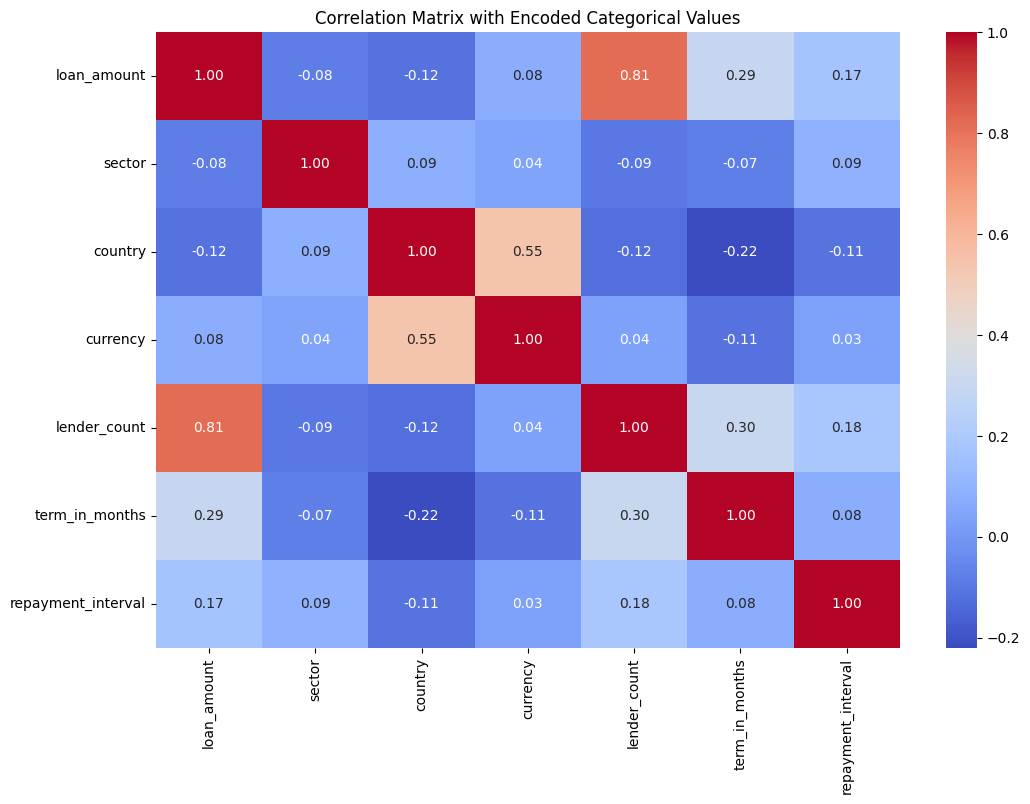

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix with Encoded Categorical Values')
plt.show()

#3. Unsupervised Machine Learning

## 3.1. Applying K-means and hierarchical clustering to the dataset

The purpose of this section is to reduce the complexity of the Kiva dataset while retaining its main patterns. K-means works well across a large number of records.

In [ ]:
# Quick display of our dataset
df_core.head()

,id,loan_amount,sector,country,currency,lender_count,term_in_months,repayment_interval
0,653051.0,300.0,Food,Pakistan,PKR,12.0,12.0,irregular
1,653053.0,575.0,Transportation,Pakistan,PKR,14.0,11.0,irregular
2,653068.0,150.0,Transportation,India,INR,6.0,43.0,bullet
3,653063.0,200.0,Arts,Pakistan,PKR,8.0,11.0,irregular
4,653084.0,400.0,Food,Pakistan,PKR,16.0,14.0,monthly


In [ ]:
# simplify the complexity of the KIVA dataset while retaining trends/patterns using K-means
df_inc_id = data[['id', 'loan_amount', 'sector', 'country', 'currency', 'lender_count', 'term_in_months', 'repayment_interval']].dropna()
q1 = df_inc_id['loan_amount'].quantile(0.25)
q3 = df_inc_id['loan_amount'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df_inc_id = df_inc_id[(df_inc_id['loan_amount']>= lower_bound) & (df_inc_id['loan_amount']<= upper_bound)]
X = df_inc_id[['loan_amount', 'term_in_months']].values

respondent_names = df_inc_id['id'].values
k = 4

kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

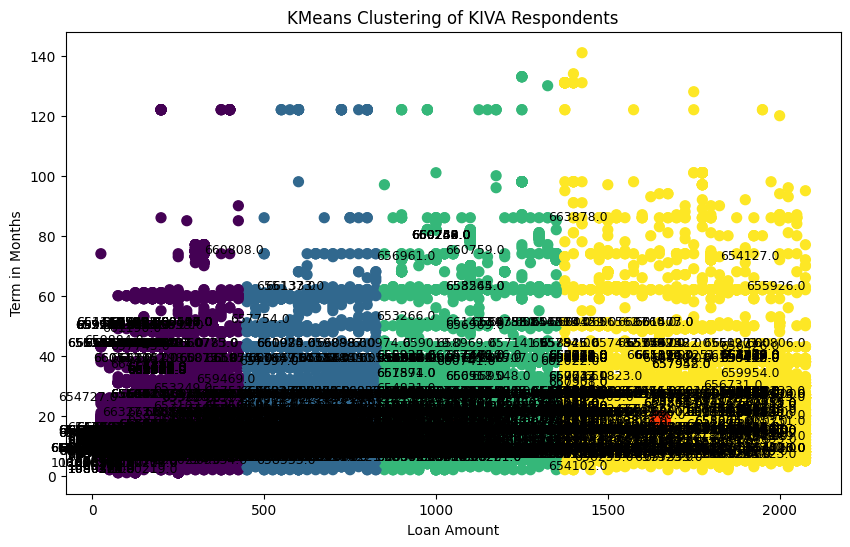

In [ ]:
# Visualize the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot the cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75)

# Annotate each point on the scatter plot
for i, respondent in enumerate(respondent_names[:10000]):
    plt.text(X[i, 0], X[i, 1], respondent, fontsize=9, ha='right')


plt.xlabel('Loan Amount')
plt.ylabel('Term in Months')
plt.title('KMeans Clustering of KIVA Respondents')
plt.show()

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 16452.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 16452.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 16452.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 16452.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 16452.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 51, cost: 15661.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 230, cost: 15499.0
Init: initializing centroids
Init: initializing clusters
Starting iterat

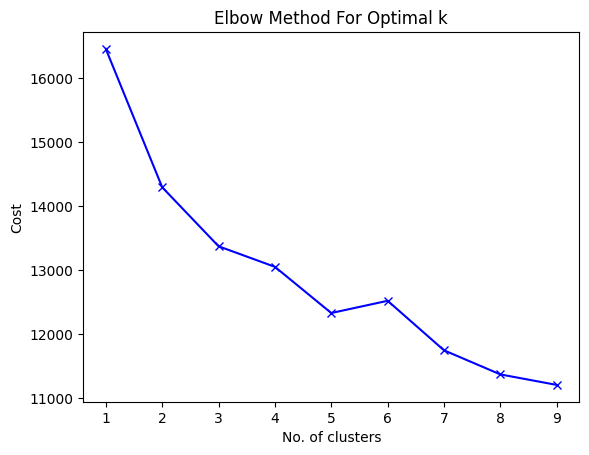

In [ ]:
# Using the elbow curve to find optimal K
cost = []
K = range(1,10)
for num_clusters in list(K):
    kmode = KModes(n_clusters=num_clusters, init = "random", n_init = 5, verbose=1)
    kmode.fit_predict(X[:10000])
    cost.append(kmode.cost_)

plt.plot(K, cost, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k')
plt.show()

This model identifies the density of clusters and distance between clusters and plots them to illustrate greater density (good) and bigger distance (good)

### 3.1.1. Hierarchical clustering — bottom-up

This approach works well with a small number of items (roughly 10–100).

In [ ]:
# So in order to display this appoach I will isolate the first 12 respondents from the dataframe
df_h = df_inc_id[:12]

In [ ]:
# In order to use the bottom-up approach we will use AgglomerativeClustering() in order to initiate the Hierarchical clustering-process
agg_cluster = AgglomerativeClustering(n_clusters=3).fit(df_h[['loan_amount', 'term_in_months']])
agg_cluster.labels_

array([0, 2, 0, 0, 1, 0, 0, 1, 1, 2, 0, 1])

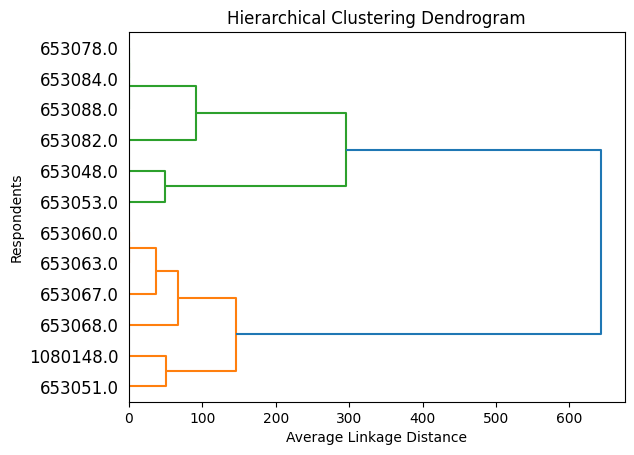

In [ ]:
# Use the linkage matrix to finish the Hierarchical clustering-process and dendrogram() to plot it
linkage_matrix = linkage(df_h[['loan_amount', 'term_in_months']], method='ward', metric='euclidean')
dendrogram(linkage_matrix, labels=df_h.id.values, orientation='right')

plt.xlabel('Average Linkage Distance')
plt.ylabel('Respondents')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

In [ ]:
# this could also be done based of countries
df_h2_1000 = df_core[df_core['sector'] == 'Food'].head(1000)
df_h2_1000.head()

,loan_amount,sector,country,currency,lender_count,term_in_months,repayment_interval
0,300.0,Food,Pakistan,PKR,12.0,12.0,irregular
4,400.0,Food,Pakistan,PKR,16.0,14.0,monthly
9,625.0,Food,Pakistan,PKR,24.0,11.0,irregular
20,250.0,Food,Pakistan,PKR,10.0,11.0,irregular
21,350.0,Food,Pakistan,PKR,13.0,12.0,irregular


In [ ]:
agg_cluster = AgglomerativeClustering(n_clusters=3).fit(df_h2_1000[['loan_amount', 'term_in_months']])
agg_cluster.labels_

array([2, 1, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 1, 0, 2, 2,
       2, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       0, 2, 2, 1, 2, 2, 2, 0, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 0,
       0, 1, 1, 2, 2, 2, 0, 0, 0, 1, 2, 2, 0, 1, 2, 0, 2, 2, 1, 2, 2, 1,
       1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 1,
       0, 0, 0, 1, 1, 2, 2, 1, 0, 2, 2, 0, 2, 1, 2, 2, 0, 1, 0, 1, 0, 2,
       2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 2, 2, 0, 1, 2, 2, 2, 1, 2, 0, 0, 2,
       2, 0, 1, 1, 0, 1, 0, 2, 0, 2, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 2,
       1, 2, 2, 0, 2, 0, 0, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 0,
       2, 0, 1, 2, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 0, 1, 0,
       2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 0, 2, 1, 0, 1,
       0, 2, 2, 2, 1, 0, 2, 0, 1, 2, 0, 2, 2, 1, 2, 0, 1, 1, 1, 1, 1, 2,
       1, 2, 1, 2, 1, 1, 2, 2, 0, 2, 2, 2, 1, 0, 2,

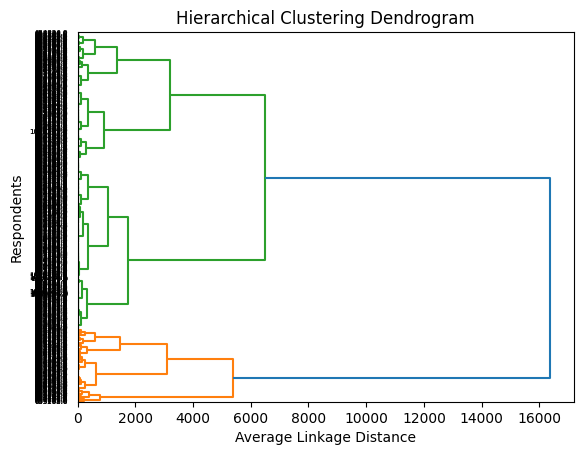

In [ ]:
# Use linkage() and dendrogram() to plot it
linkage_matrix = linkage(df_h2_1000[['loan_amount', 'term_in_months']], method='ward', metric='euclidean')
dendrogram(linkage_matrix, labels=df_h2_1000.id.values, orientation='right')


plt.xlabel('Average Linkage Distance')
plt.ylabel('Respondents')
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

## 3.2. Recommendation system

The purpose of this section is to prototype a recommendation system that uses unsupervised learning (matrix factorisation via Truncated SVD) to surface loans that are similar based on lending patterns.

In [ ]:
# This is a big data set, so in order to run a recommendationsystem I will isolate a sample of the data set
df_core_rec = df_inc_id[['id', 'loan_amount']].dropna()
df_core_rec = df_core_rec[:10000]

In [ ]:
# A. Initialize label encoders
le_users = LabelEncoder()
le_items = LabelEncoder()

In [ ]:
# A. Label encode the loan ids and loan amounts
df_core_rec['id'] = le_users.fit_transform(df_core_rec['id'])
df_core_rec['loan_amount'] = le_items.fit_transform(df_core_rec['loan_amount'])

In [ ]:
# B. Matrix Creation
matrix_loan_user = df_core_rec.groupby(['loan_amount','id']).agg('size').unstack(fill_value=0)

In [ ]:
# Matrix Creation

matrix_loan_user = pd.crosstab(df_core_rec['loan_amount'], df_core_rec['id'])

# Matrix Transpose
matrix_loan_user = matrix_loan_user.T

(82, 10000)

In [ ]:
svd = TruncatedSVD(n_components=5, n_iter=7, random_state=42)

In [ ]:
#latent features capture a user's preference for certain types of places
matrix_loan_user_dr = svd.fit_transform(matrix_loan_user)
matrix_loan_user_dr.shape

(10000, 5)

In [ ]:
# Calculate the cosine distances between all pairs of places in the matrix_places
cosine_distance_matrix_loan_user_dr = cosine_distances(matrix_loan_user_dr)
cosine_distance_matrix_loan_user_dr.shape

(10000, 10000)

In [ ]:
# Define a function to perform this process
def find_similar_loans(loan_index, nrec):
    # Ensure the loan index is valid within the bounds of the matrix
    if loan_index >= cosine_distance_matrix_loan_user_dr.shape[0]:
        raise ValueError(f"Loan index {loan_index} is out of bounds.")

    # Retrieve the cosine distances for this loan from the matrix
    distances = cosine_distance_matrix_loan_user_dr[loan_index, :]

    # Get indices of the nrec closest loans (smallest distances)
    closest_indices = np.argsort(distances)[:nrec]

    return closest_indices  # Return the closest loan indices directly

# Call the function
find_similar_loans(200, 5)

array([2043, 7722,  756, 1879, 7542])

#4. Supervised Machine Learning

## 4.1. Linear regression:

In [ ]:
# A quick display of the dataset
df_core.head()

,loan_amount,sector,country,currency,lender_count,term_in_months,repayment_interval
0,300.0,Food,Pakistan,PKR,12.0,12.0,irregular
1,575.0,Transportation,Pakistan,PKR,14.0,11.0,irregular
2,150.0,Transportation,India,INR,6.0,43.0,bullet
3,200.0,Arts,Pakistan,PKR,8.0,11.0,irregular
4,400.0,Food,Pakistan,PKR,16.0,14.0,monthly


In [ ]:
# One-Hot Encoding for 'cat_bins'
df_dumb = pd.get_dummies(df_core, columns=['sector', 'country', 'currency', 'repayment_interval'], drop_first=True)

# Display the first few rows to verify
df_dumb.head()

,loan_amount,lender_count,term_in_months,sector_Arts,sector_Clothing,sector_Construction,sector_Education,sector_Entertainment,sector_Food,sector_Health,...,currency_XAF,currency_XCD,currency_XOF,currency_YER,currency_ZAR,currency_ZMW,currency_ZWD,repayment_interval_irregular,repayment_interval_monthly,repayment_interval_weekly
0,300.0,12.0,12.0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,575.0,14.0,11.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,150.0,6.0,43.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,200.0,8.0,11.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,400.0,16.0,14.0,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# List of features to scale
features_to_scale = ['lender_count', 'term_in_months']

# Fit and transform the features
df_dumb[features_to_scale] = scaler.fit_transform(df_dumb[features_to_scale])

# Display the first few rows to verify
df_dumb.head()

,loan_amount,lender_count,term_in_months,sector_Arts,sector_Clothing,sector_Construction,sector_Education,sector_Entertainment,sector_Food,sector_Health,...,currency_XAF,currency_XCD,currency_XOF,currency_YER,currency_ZAR,currency_ZMW,currency_ZWD,repayment_interval_irregular,repayment_interval_monthly,repayment_interval_weekly
0,300.0,-0.299174,-0.191793,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,575.0,-0.149597,-0.319414,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,150.0,-0.747904,3.764440,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,200.0,-0.598327,-0.319414,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,400.0,-0.000021,0.063447,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# Define the target variable
y = df_dumb['loan_amount']

# Define feature columns
feature_cols = df_dumb.columns[1:]

# Define the feature set
X = df_dumb[feature_cols]

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize the Linear Regression model
model_lr = LinearRegression()

# Train the model
model_lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions on the test set
y_pred_lr = model_lr.predict(X_test)

In [ ]:
# Calculate evaluation metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Linear Regression R² Score: {r2_lr:.2f}")

Linear Regression Mean Squared Error (MSE): 54370.39
Linear Regression Mean Absolute Error (MAE): 158.96
Linear Regression R² Score: 0.72


<ipython-input-110-f07d211e0fda>:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')


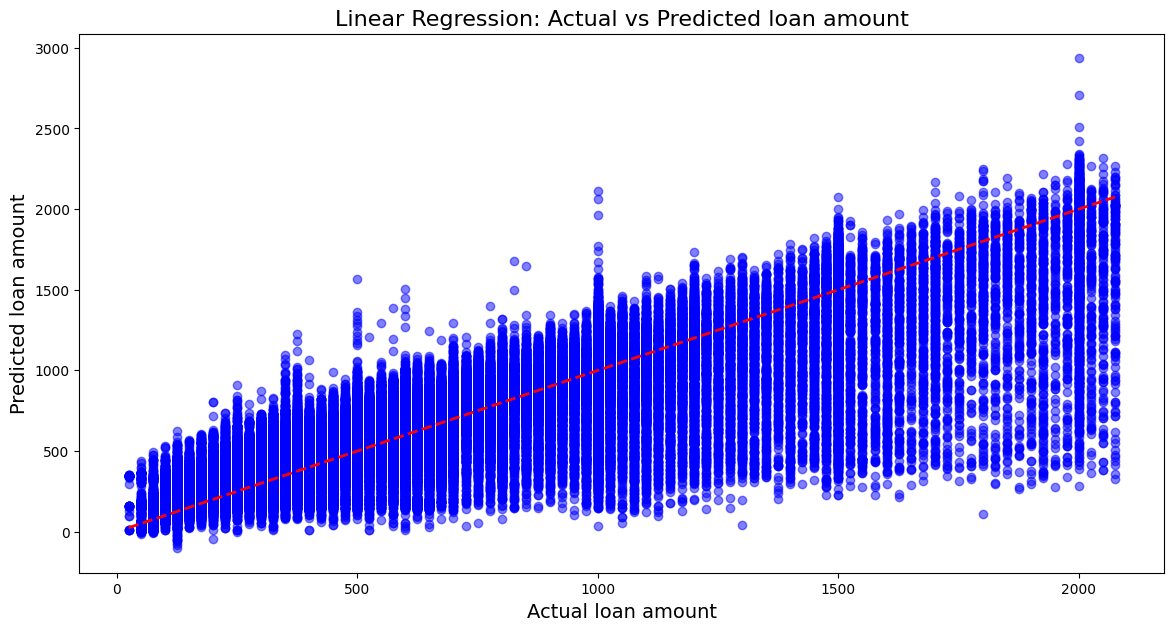

In [ ]:
# Plot actual vs predicted values
plt.figure(figsize=(14,7))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.title('Linear Regression: Actual vs Predicted loan amount', fontsize=16)
plt.xlabel('Actual loan amount', fontsize=14)
plt.ylabel('Predicted loan amount', fontsize=14)
plt.show()

## 4.2 Random forrest

In order to make a regression based of the Random Forrest i'll have to isolate a sample from the previously used data

In [ ]:
# Sample
df_sampler = df_core[:10000]

Mean Squared Error: 29060.5220837837
R-squared Score: 0.8590112077949406


<ipython-input-40-b14333c72f83>:50: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')


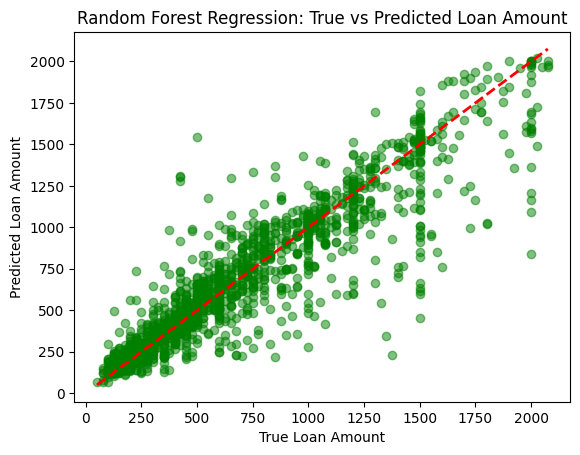

In [ ]:
# Step 1: Preprocess the categorical variables (using OneHotEncoding)
X = df_sampler[['sector', 'country', 'currency', 'repayment_interval', 'lender_count', 'term_in_months']]  # Features
y = df_sampler['loan_amount']  # Dependent variable (Target)

# Define categorical and numerical features
categorical_features = ['sector', 'country', 'currency', 'repayment_interval']
numerical_features = ['lender_count', 'term_in_months']

# Use OneHotEncoder to transform categorical data, while keeping numerical features unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features)
    ], remainder='passthrough')  # Leave numerical columns as they are

# Apply the preprocessor to the dataset
X_encoded = preprocessor.fit_transform(X)

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Step 3: Fit the Random Forest Regressor on the training set
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Make predictions on the test set
y_pred = rf.predict(X_test)

# Step 5: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

# Step 6: Plot the results
# Plot true vs predicted values
plt.scatter(y_test, y_pred, color='green', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')
plt.xlabel('True Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.title('Random Forest Regression: True vs Predicted Loan Amount')
plt.show()

##4.3. Time to do some SHAP on loan_amount

###4.3.1. Feature Engineering

We'll now encode categorical variables and scale numerical features.

In [ ]:
df.head()

,loan_amount,sector,country,currency,lender_count,term_in_months,repayment_interval
0,300.0,Food,Pakistan,PKR,12.0,12.0,irregular
1,575.0,Transportation,Pakistan,PKR,14.0,11.0,irregular
2,150.0,Transportation,India,INR,6.0,43.0,bullet
3,200.0,Arts,Pakistan,PKR,8.0,11.0,irregular
4,400.0,Food,Pakistan,PKR,16.0,14.0,monthly


In [ ]:
# Separate features and target
X = df.drop('loan_amount', axis=1)
y = df['loan_amount']

# One-hot encode categorical variables
ohe = OneHotEncoder() # be careful - output is a sparse matrix
cat_features = ['sector', 'country', 'currency', 'repayment_interval']
X_cat = pd.DataFrame(ohe.fit_transform(X[cat_features]).todense(), columns=ohe.get_feature_names_out(cat_features))

# Scale numerical features
scaler = StandardScaler()
num_features = ['lender_count', 'term_in_months']
X_num = pd.DataFrame(scaler.fit_transform(X[num_features]), columns=num_features)

# Combine encoded categorical and scaled numerical features
X_processed = pd.concat([X_num, X_cat], axis=1)

print("Shape of processed features:", X_processed.shape)

Shape of processed features: (671205, 175)


### 4.3.2. Model Training and Evaluation

We'll use XGBoost for our regression task.

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.20, random_state=42)

# Train XGBoost model
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)

# Evaluate the model
train_rmse = np.sqrt(mean_squared_error(y_train, model_xgb.predict(X_train)))
test_rmse = np.sqrt(mean_squared_error(y_test, model_xgb.predict(X_test)))

print(f"Train Root Mean Squared Error: {train_rmse:.2f}")
print(f"Test Root Mean Squared Error: {test_rmse:.2f}")

Train Root Mean Squared Error: 459.12
Test Root Mean Squared Error: 616.49


### 4.3.3. Model Explainability

Understanding how our model makes predictions is crucial. We'll use SHAP (SHapley Additive exPlanations) values to interpret our model.

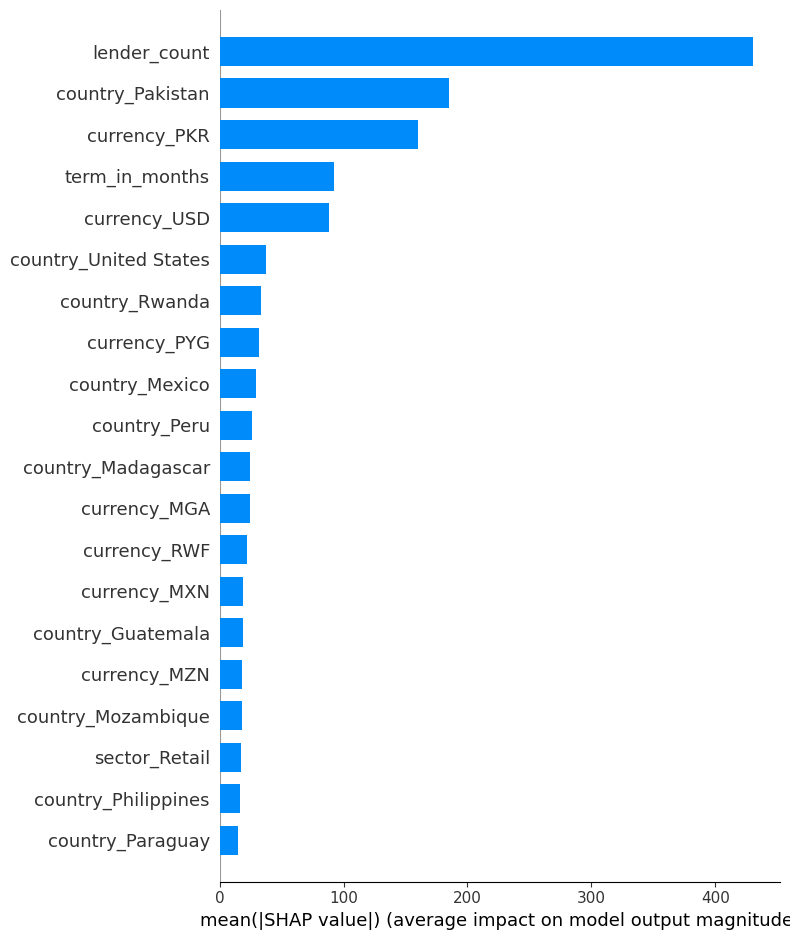

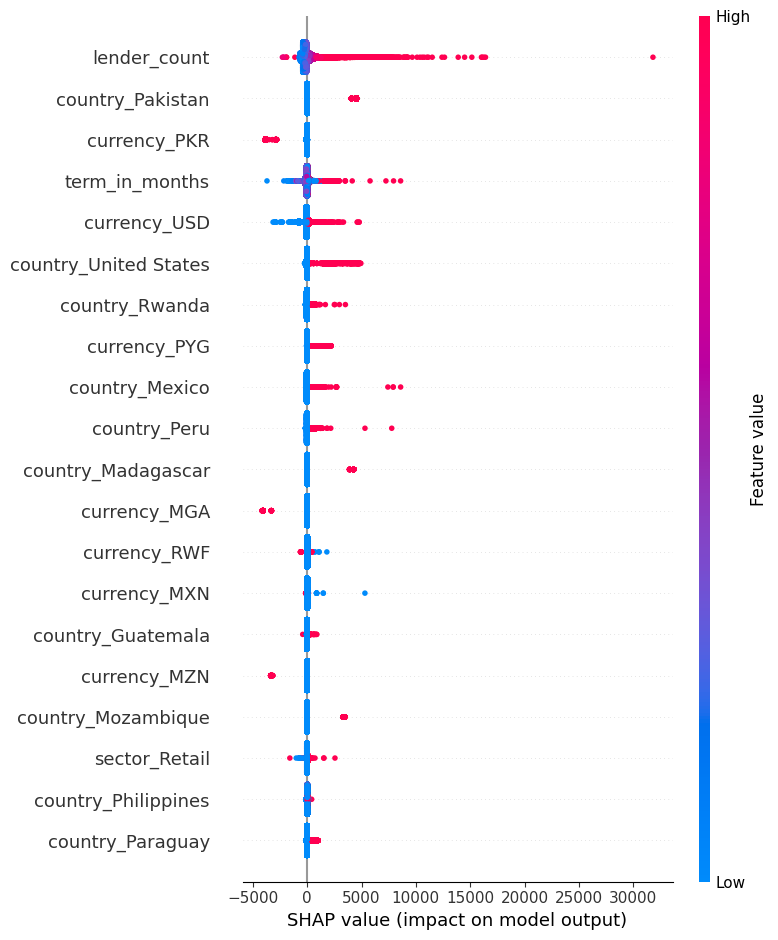

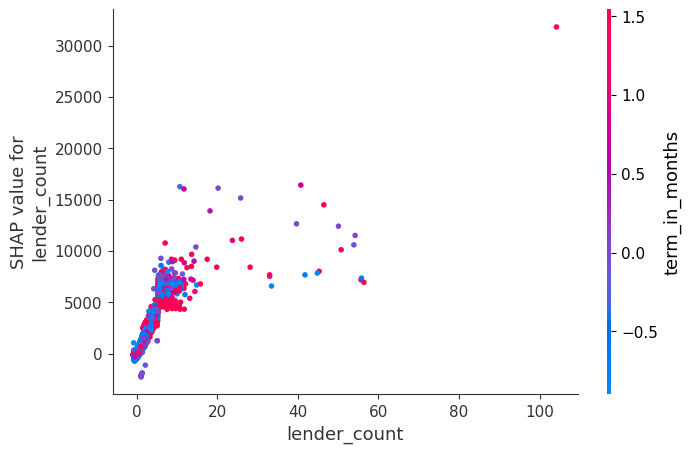

In [ ]:
# Create a SHAP explainer
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

# Plot feature importances
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Plot SHAP values
shap.summary_plot(shap_values, X_test)

# Plot dependence for the most important feature
most_important_feature = X_test.columns[np.argmax(np.abs(shap_values).mean(0))]
shap.dependence_plot(most_important_feature, shap_values, X_test)

In [ ]:
# Time to download our trained model and input it into our streamlit app
joblib.dump(model_xgb, 'model_xgb.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(ohe, 'ohe.joblib')

['ohe.joblib']